In [9]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model_qroq = ChatGroq(model="openai/gpt-oss-120b")

In [7]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)

tavily_search_tool.invoke("What is the current AI news?")

{'query': 'What is the current AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.reuters.com/technology/artificial-intelligence',
   'title': 'AI News | Latest Headlines and Developments',
   'content': "More AI News · UK's National Grid bets $1.75 billion on AI power boom with Joulent investment · Unchecked AI progress may pose catastrophic risks, UN panel",
   'score': 0.67706895,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.6708892,
   'raw_content': None},
  {'url': 'https://www.reddit.com/r/AISEOInsider/comments/1rs1o1v/latest_ai_news_the_biggest_ai_announcements_right',
   'title': 'Latest AI News: The Biggest AI Announcements Right Now : r ...',
   'content': 'Meta Buying Moltbook 

In [5]:
tool

<function langchain_core.tools.convert.tool(name_or_callable: str | collections.abc.Callable[..., typing.Any] | None = None, runnable: Optional[langchain_core.runnables.base.Runnable[Any, Any]] = None, *args: Any, description: str | None = None, return_direct: bool = False, args_schema: type[pydantic.main.BaseModel] | type[pydantic.v1.main.BaseModel] | dict[str, typing.Any] | None = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True, extras: dict[str, typing.Any] | None = None) -> langchain_core.tools.base.BaseTool | collections.abc.Callable[[typing.Union[collections.abc.Callable[..., typing.Any], langchain_core.runnables.base.Runnable[typing.Any, typing.Any]]], langchain_core.tools.base.BaseTool]>

In [4]:
from langchain.tools import tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

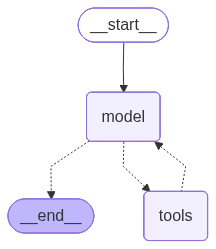

In [11]:
from langchain.agents import create_agent

agent = create_agent(
    model=model_qroq,
    tools=[tavily_search_tool,calc]
)

agent

In [12]:
user_input="What is the current AI news for anthropic and then calculate 10+10"

for step in agent.stream(
    {"messages":user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for anthropic and then calculate 10+10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_53cf0839-39a0-49dd-bc5f-fdf22545ec4c)
 Call ID: fc_53cf0839-39a0-49dd-bc5f-fdf22545ec4c
  Args:
    query: latest news Anthropic AI 2024 July
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news Anthropic AI 2024 July", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/anthropic-artificial-intelligence-trump-fable-mythos-d9cc7df5c02e93837d0f0bfb24d5cfd2", "title": "Anthropic says it has taken its latest AI models offline | AP News", "content": "Dario Amodei, CEO & Co-Founder of Anthropic, speaks on a panel at the convening of the International Network of

In [15]:
final_step = None
for step in agent.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    stream_mode="values"
):
    final_step = step  

print(final_step["messages"][-1].text())

**Current AI news for Anthropic (as of July 1‑2 2026)**  

| Date (2026) | Headline | Key Points |
|-------------|----------|------------|
| **July 1** | **U.S. lifts export‑control restrictions on Anthropic’s top‑tier models Claude Fable 5 and Mythos 5** | • The Department of Commerce removed the export licence requirement after Anthropic agreed to “proactively detect and address security risks,” share guard‑rail details, and report malicious activity. <br>• Anthropic will begin restoring access to these models for international users and business customers starting the next day. <br>• The restriction had been imposed in late June when the government flagged potential “jail‑break” vulnerabilities and classified the models as a “supply‑chain risk.”<br>• Sources: Al Jazeera (https://www.aljazeera.com/economy/2026/7/1/us-lifts-restrictions‑on‑powerful‑ai‑models‑fable‑mythos‑anthropic‑says) and Forbes (https://www.forbes.com/sites/siladityaray/2026/07/01/trump‑administration‑lifts‑export‑

/Users/manannghodasara/langchain/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3748: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  exec(code_obj, self.user_global_ns, self.user_ns)
